In [ ]:
!pip install yfinance torch torchdiffeq scikit-learn

IMPORT LIBRATY

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchdiffeq import odeint

import random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

plt.style.use("default")

print("Library berhasil diimport.")

Library berhasil diimport.


RANDOM SEED

In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cpu")

print("Device :", device)
print("Seed   : 42")

Device : cpu
Seed   : 42


DOWNLOAD DATA

[*********************100%***********************]  1 of 1 completed

Jumlah data : 283


,Close
Date,
2025-06-02,9100.0
2025-06-03,9050.0
2025-06-04,8975.0
2025-06-05,8925.0
2025-06-10,9100.0


,Close
Date,
2026-07-24,6275.0
2026-07-27,6300.0
2026-07-28,6225.0
2026-07-29,6275.0
2026-07-30,6450.0


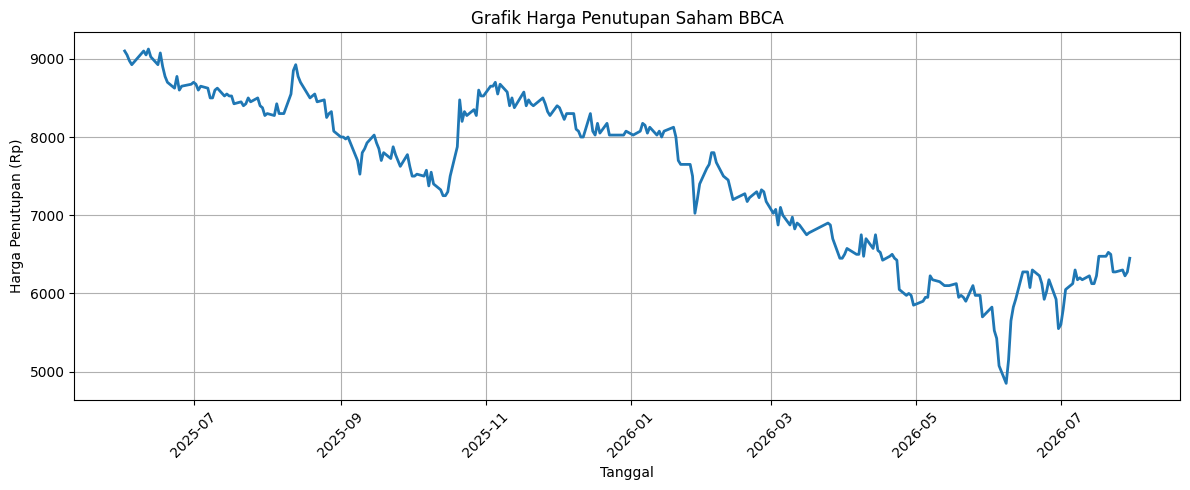

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

ticker = "BBCA.JK"

data = yf.download(
    ticker,
    start="2025-06-01",
    end="2026-07-31",
    auto_adjust=False
)

data = data[['Close']]

# Mengubah MultiIndex menjadi kolom biasa
data.columns = ['Close']

data.dropna(inplace=True)

print("Jumlah data :", len(data))

display(data.head())
display(data.tail())

# Menampilkan grafik harga penutupan
plt.figure(figsize=(12,5))
plt.plot(data.index, data["Close"], linewidth=2)

plt.title("Grafik Harga Penutupan Saham BBCA")
plt.xlabel("Tanggal")
plt.ylabel("Harga Penutupan (Rp)")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

PREPROCESSING DATASET

             Close  LogReturn
Date                         
2025-06-03  9050.0  -0.005510
2025-06-04  8975.0  -0.008322
2025-06-05  8925.0  -0.005587
2025-06-10  9100.0   0.019418
2025-06-11  9050.0  -0.005510


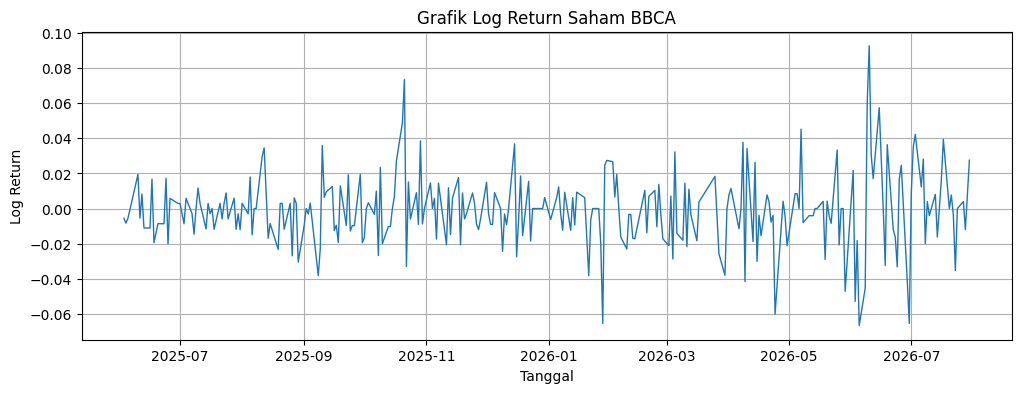

In [ ]:
data["LogReturn"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

data.dropna(inplace=True)

print(data.head())

plt.figure(figsize=(12,4))

plt.plot(
    data.index,
    data["LogReturn"],
    linewidth=1
)

plt.title("Grafik Log Return Saham BBCA")
plt.xlabel("Tanggal")
plt.ylabel("Log Return")
plt.grid(True)

plt.show()

DEFINISI NEURAL ODE

In [ ]:
class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(1,64),

            nn.Tanh(),

            nn.Linear(64,1)

        )

    def forward(self, t, y):

        return self.net(y)


print("Model Neural ODE berhasil dibuat.")

Model Neural ODE berhasil dibuat.


METODE EULER

In [ ]:
def euler_method(func, y0, t, verbose=False):

    y = [y0.view(1)]

    h = t[1]-t[0]

    if verbose:
        print("\n--- PROSES INTERNAL GRADIEN EULER ---")

    for i in range(1,len(t)):

        grad = func(None, y[-1].view(1,1))

        if verbose:

            print(

                f"Hari {i} -> "

                f"Input y_{i-1}: {y[-1].item():.8f} | "

                f"Gradien : {grad.item():.8f}"

            )

        y_next = y[-1] + h*grad

        y.append(y_next.view(1))

    return torch.stack(y)

METODE RK4

In [ ]:
def rk4_method(func, y0, t, verbose=False):

    y = [y0.view(1)]

    h = t[1]-t[0]

    if verbose:
        print("\n--- PROSES INTERNAL KOEFISIEN RK4 ---")

    for i in range(1,len(t)):

        yi = y[-1].view(1,1)

        k1 = func(None, yi)

        k2 = func(None, yi + (h/2)*k1)

        k3 = func(None, yi + (h/2)*k2)

        k4 = func(None, yi + h*k3)

        if verbose:

            print(

                f"Hari {i} -> "

                f"k1={k1.item():.8f} | "

                f"k2={k2.item():.8f} | "

                f"k3={k3.item():.8f} | "

                f"k4={k4.item():.8f}"

            )

        y_next = yi + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

        y.append(y_next.view(1))

    return torch.stack(y)

### **VALIDASI MANUAL**

PERSIAPAN VALIDASI MANUAL

In [ ]:
# ==========================================================
# PERSIAPAN VALIDASI MANUAL
# ==========================================================

# Parameter Validasi

tanggal_prediksi = "2026-06-29"
jumlah_hari = 5      # 1 minggu historis

# ==========================================================
# Menentukan posisi tanggal prediksi
# ==========================================================

idx = data.index.get_loc(tanggal_prediksi)

# ==========================================================
# Data historis (22 Juni - 26 Juni 2026)
# ==========================================================

data_input = data.iloc[idx-jumlah_hari:idx].copy()

# ==========================================================
# Data aktual (29 Juni - 3 Juli 2026)
# ==========================================================

data_target = data.iloc[idx:idx+5].copy()

harga_aktual = data_target["Close"].values.flatten()

# ==========================================================
# Harga awal
# ==========================================================

P0 = data_input["Close"].iloc[-1].item()

# ==========================================================
# Standardisasi
# ==========================================================

scaler = StandardScaler()

scaler.fit(
    data_input[["LogReturn"]]
)

train_scaled = scaler.transform(
    data_input[["LogReturn"]]
)

# ==========================================================
# Tensor Training
# ==========================================================

train_tensor = torch.tensor(
    train_scaled,
    dtype=torch.float32
).to(device)

# ==========================================================
# Data awal prediksi
# ==========================================================

y0_raw = data_input["LogReturn"].iloc[-1].item()

y0_scaled = scaler.transform(
    np.array([[y0_raw]])
)[0, 0]

test_tensor = torch.tensor(
    [y0_scaled],
    dtype=torch.float32
).to(device)

# ==========================================================
# Informasi
# ==========================================================

print("Persiapan validasi manual selesai.")
print()

print(
    "Data historis :",
    data_input.index[0].date(),
    "sampai",
    data_input.index[-1].date()
)

print(
    "Data target   :",
    data_target.index[0].date(),
    "sampai",
    data_target.index[-1].date()
)

Persiapan validasi manual selesai.

Data historis : 2026-06-22 sampai 2026-06-26
Data target   : 2026-06-29 sampai 2026-07-03


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


TRAINING NEURAL  ODE (VALIDASI MANUAL)

Training selesai.
Loss Awal  : 0.612110
Loss Akhir : 0.823327


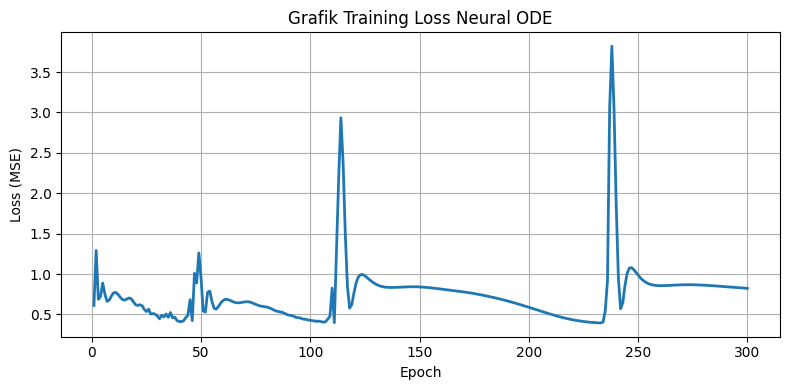

In [ ]:
# Agar bobot awal selalu sama

set_seed(42)

# Membuat model

func = ODEFunc().to(device)

# Optimizer dan Loss Function

optimizer = torch.optim.Adam(
    func.parameters(),
    lr=0.01
)

loss_fn = nn.MSELoss()

# Waktu Training

t_train = torch.arange(
    len(train_tensor),
    dtype=torch.float32
).to(device)

# Training

epochs = 300

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = odeint(
        func,
        train_tensor[0],
        t_train
    )

    loss = loss_fn(
        pred.squeeze(),
        train_tensor.squeeze()
    )

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

print("Training selesai.")

print(f"Loss Awal  : {loss_history[0]:.6f}")
print(f"Loss Akhir : {loss_history[-1]:.6f}")

# Menampilkan grafik loss
plt.figure(figsize=(8,4))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.title("Grafik Training Loss Neural ODE")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)

plt.tight_layout()
plt.show()

VALIDASI MANUAL

In [ ]:
print("="*70)
print("VALIDASI MANUAL NEURAL ODE")
print("="*70)

# ==========================================================
# Informasi Standardisasi
# ==========================================================

mu = scaler.mean_[0]
sigma = scaler.scale_[0]

print(f"Mean (μ)               : {mu:.8f}")
print(f"Standar Deviasi (σ)    : {sigma:.8f}")
print()

print(f"Harga Awal (P0)        : Rp {P0:,.2f}")
print(f"Log Return Awal        : {y0_raw:.8f}")
print(f"Log Return Scaled      : {y0_scaled:.8f}")

# ==========================================================
# Gradien awal Neural ODE
# ==========================================================

func.eval()

with torch.no_grad():

    grad_awal = func(
        None,
        test_tensor.view(1,1)
    ).item()

print(f"Gradien Awal f(y0)     : {grad_awal:.8f}")

# ==========================================================
# Titik Evaluasi
# ==========================================================

t_eval = torch.arange(
    0,
    5,
    1,
    dtype=torch.float32
).to(device)

print(f"Step Size (h)          : {(t_eval[1]-t_eval[0]).item():.1f}")

# ==========================================================
# Prediksi Euler dan RK4
# ==========================================================

with torch.no_grad():

    y_pred_euler_scaled = euler_method(
        func,
        test_tensor,
        t_eval,
        verbose=True
    )

    y_pred_rk4_scaled = rk4_method(
        func,
        test_tensor,
        t_eval,
        verbose=True
    )

# ==========================================================
# HASIL NORMALISASI
# ==========================================================

print()
print("="*70)
print("HASIL NORMALISASI")
print("="*70)

print("Euler")

for i, nilai in enumerate(y_pred_euler_scaled.squeeze().cpu().numpy()):
    print(f"y{i} = {nilai:.8f}")

print()

print("RK4")

for i, nilai in enumerate(y_pred_rk4_scaled.squeeze().cpu().numpy()):
    print(f"y{i} = {nilai:.8f}")

# ==========================================================
# INVERSE STANDARD SCALER
# ==========================================================

log_euler = scaler.inverse_transform(
    y_pred_euler_scaled.cpu().numpy().reshape(-1,1)
).flatten()

log_rk4 = scaler.inverse_transform(
    y_pred_rk4_scaled.cpu().numpy().reshape(-1,1)
).flatten()

print()
print("="*70)
print("HASIL LOG RETURN")
print("="*70)

print("Euler")

for i, nilai in enumerate(log_euler):
    print(f"r{i} = {nilai:.8f}")

print()

print("RK4")

for i, nilai in enumerate(log_rk4):
    print(f"r{i} = {nilai:.8f}")

# ==========================================================
# KONVERSI KE HARGA SAHAM
# ==========================================================

harga_pred_euler = P0 * np.exp(log_euler)
harga_pred_rk4 = P0 * np.exp(log_rk4)

print()
print("="*70)
print("HASIL KONVERSI KE HARGA SAHAM")
print("="*70)

print("Hari | Euler (Rp) | RK4 (Rp) | Aktual (Rp)")
print("-"*75)

for i in range(len(harga_aktual)):
    print(
        f"{i+1:>4} | "
        f"{harga_pred_euler[i]:>12,.2f} | "
        f"{harga_pred_rk4[i]:>10,.2f} | "
        f"{harga_aktual[i]:>10,.2f}"
    )

print()
print("Validasi manual selesai.")
print("Seluruh nilai di atas dapat digunakan untuk perhitungan manual Euler dan RK4.")

VALIDASI MANUAL NEURAL ODE
Mean (μ)               : -0.00400815
Standar Deviasi (σ)    : 0.02150507

Harga Awal (P0)        : Rp 6,175.00
Log Return Awal        : 0.02459140
Log Return Scaled      : 1.32989828
Gradien Awal f(y0)     : -0.60795695
Step Size (h)          : 1.0

--- PROSES INTERNAL GRADIEN EULER ---
Hari 1 -> Input y_0: 1.32989824 | Gradien : -0.60795695
Hari 2 -> Input y_1: 0.72194129 | Gradien : -0.19878551
Hari 3 -> Input y_2: 0.52315581 | Gradien : -0.06405399
Hari 4 -> Input y_3: 0.45910183 | Gradien : -0.02129701

--- PROSES INTERNAL KOEFISIEN RK4 ---
Hari 1 -> k1=-0.60795695 | k2=-0.40663782 | k3=-0.47454846 | k4=-0.29014224
Hari 2 -> k1=-0.31147572 | k2=-0.20480466 | k3=-0.24130481 | k4=-0.14646703
Hari 3 -> k1=-0.15753719 | k2=-0.10412344 | k3=-0.12218770 | k4=-0.07487146
Hari 4 -> k1=-0.08026028 | k2=-0.05333821 | k3=-0.06235292 | k4=-0.03849300

HASIL NORMALISASI
Euler
y0 = 1.32989824
y1 = 0.72194129
y2 = 0.52315581
y3 = 0.45910183
y4 = 0.43780482

RK4
y0 = 1.3

### **EKSPERIMEN**

FUNGSI EKSPERIMEN

In [ ]:
def prediksi_model(jumlah_hari):

    print("=" * 70)
    print(f"RENTANG HISTORIS : {jumlah_hari} HARI")
    print("=" * 70)

    # ============================================================
    # Data historis
    # ============================================================

    idx = data.index.get_loc(tanggal_prediksi)

    data_input = data.iloc[idx-jumlah_hari:idx].copy()
    data_target = data.iloc[idx:idx+5].copy()

    harga_aktual = data_target["Close"].values.flatten()

    P0 = data_input["Close"].iloc[-1].item()

    # ============================================================
    # Standardisasi
    # ============================================================

    scaler = StandardScaler()

    scaler.fit(data_input[["LogReturn"]])

    train_scaled = scaler.transform(
        data_input[["LogReturn"]]
    )

    train_tensor = torch.tensor(
        train_scaled,
        dtype=torch.float32
    ).to(device)

    y0_raw = data_input["LogReturn"].iloc[-1].item()

    y0_scaled = scaler.transform(
        np.array([[y0_raw]])
    )[0, 0]

    test_tensor = torch.tensor(
        [y0_scaled],
        dtype=torch.float32
    ).to(device)

    # ============================================================
    # Training Neural ODE
    # ============================================================

    set_seed(42)

    func = ODEFunc().to(device)

    optimizer = torch.optim.Adam(
        func.parameters(),
        lr=0.01
    )

    loss_fn = nn.MSELoss()

    t_train = torch.arange(
        len(train_tensor),
        dtype=torch.float32
    ).to(device)

    for _ in range(300):

        optimizer.zero_grad()

        pred = odeint(
            func,
            train_tensor[0],
            t_train,
            method="rk4"
        )

        loss = loss_fn(
            pred.squeeze(),
            train_tensor.squeeze()
        )

        loss.backward()
        optimizer.step()

    # ============================================================
    # Prediksi
    # ============================================================

    t_eval = torch.arange(
        0,
        5,
        1,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        y_euler = euler_method(
            func,
            test_tensor,
            t_eval,
            verbose=False
        )

        y_rk4 = rk4_method(
            func,
            test_tensor,
            t_eval,
            verbose=False
        )

    # ============================================================
    # Denormalisasi
    # ============================================================

    log_euler = scaler.inverse_transform(
    y_euler.cpu().numpy().reshape(-1, 1)
    ).flatten()

    log_rk4 = scaler.inverse_transform(
    y_rk4.cpu().numpy().reshape(-1, 1)
    ).flatten()

    harga_euler = P0 * np.exp(log_euler)
    harga_rk4 = P0 * np.exp(log_rk4)

    # ============================================================
    # Error
    # ============================================================

    error_euler = np.abs(harga_aktual - harga_euler)
    error_rk4 = np.abs(harga_aktual - harga_rk4)

    mae_euler = np.mean(error_euler)
    mae_rk4 = np.mean(error_rk4)

    rmse_euler = np.sqrt(np.mean(error_euler**2))
    rmse_rk4 = np.sqrt(np.mean(error_rk4**2))

    mape_euler = np.mean(error_euler / harga_aktual) * 100
    mape_rk4 = np.mean(error_rk4 / harga_aktual) * 100

    # ============================================================
    # Tabel prediksi
    # ============================================================

    hasil_prediksi = pd.DataFrame({

        "Tanggal": data_target.index.strftime("%d-%m-%Y"),

        "Aktual": np.round(harga_aktual, 2),

        "Euler": np.round(harga_euler, 2),

        "RK4": np.round(harga_rk4, 2),

        "Error Euler": np.round(error_euler, 2),

        "Error RK4": np.round(error_rk4, 2)

    })

    print()
    print("HASIL PREDIKSI")
    print("-" * 90)

    display(hasil_prediksi)

    # ============================================================
    # Evaluasi
    # ============================================================

    print()

    print(f"MAE Euler  : {mae_euler:.4f}")
    print(f"RMSE Euler : {rmse_euler:.4f}")
    print(f"MAPE Euler : {mape_euler:.4f}%")

    print()

    print(f"MAE RK4    : {mae_rk4:.4f}")
    print(f"RMSE RK4   : {rmse_rk4:.4f}")
    print(f"MAPE RK4   : {mape_rk4:.4f}%")

    return {

        "Rentang": jumlah_hari,

        "MAE Euler": mae_euler,
        "RMSE Euler": rmse_euler,
        "MAPE Euler": mape_euler,

        "MAE RK4": mae_rk4,
        "RMSE RK4": rmse_rk4,
        "MAPE RK4": mape_rk4

    }

PREDIKSI DENGAN RENTANG WAKTU DATA 1 MINGGU

In [ ]:
hasil_1_minggu = prediksi_model(5)

RENTANG HISTORIS : 5 HARI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



HASIL PREDIKSI
------------------------------------------------------------------------------------------


,Tanggal,Aktual,Euler,RK4,Error Euler,Error RK4
0,29-06-2026,5925.0,6328.729980,6328.729980,403.73,403.73
1,30-06-2026,5550.0,6414.529785,6416.020020,864.53,866.02
2,01-07-2026,5600.0,6502.899902,6502.180176,902.90,902.19
3,02-07-2026,5800.0,6587.569824,6584.160156,787.57,784.16
4,03-07-2026,6050.0,6667.810059,6662.410156,617.81,612.41



MAE Euler  : 715.3055
RMSE Euler : 738.5893
MAPE Euler : 12.4609%

MAE RK4    : 713.7019
RMSE RK4   : 737.1405
MAPE RK4   : 12.4342%


PREDIKSI DENGAN RENTANG WAKTU DATA 2 MINGGU

In [ ]:
hasil_2_minggu = prediksi_model(10)

RENTANG HISTORIS : 10 HARI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



HASIL PREDIKSI
------------------------------------------------------------------------------------------


,Tanggal,Aktual,Euler,RK4,Error Euler,Error RK4
0,29-06-2026,5925.0,6328.729980,6328.729980,403.73,403.73
1,30-06-2026,5550.0,6230.490234,6256.790039,680.49,706.79
2,01-07-2026,5600.0,6196.180176,6219.009766,596.18,619.01
3,02-07-2026,5800.0,6182.770020,6198.600098,382.77,398.60
4,03-07-2026,6050.0,6177.350098,6187.419922,127.35,137.42



MAE Euler  : 438.1060
RMSE Euler : 478.3793
MAPE Euler : 7.6852%

MAE RK4    : 453.1130
RMSE RK4   : 494.6726
MAPE RK4   : 7.9494%


PREDIKSI DENGAN RENTANG WAKTU DATA 1 BULAN

In [ ]:
hasil_1_bulan = prediksi_model(20)

RENTANG HISTORIS : 20 HARI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



HASIL PREDIKSI
------------------------------------------------------------------------------------------


,Tanggal,Aktual,Euler,RK4,Error Euler,Error RK4
0,29-06-2026,5925.0,6328.729980,6328.729980,403.73,403.73
1,30-06-2026,5550.0,6120.629883,6227.680176,570.63,677.68
2,01-07-2026,5600.0,6224.209961,6200.500000,624.21,600.50
3,02-07-2026,5800.0,6173.129883,6193.100098,373.13,393.10
4,03-07-2026,6050.0,6198.919922,6191.089844,148.92,141.09



MAE Euler  : 424.1269
RMSE Euler : 455.9984
MAPE Euler : 7.4275%

MAE RK4    : 443.2210
RMSE RK4   : 481.1006
MAPE RK4   : 7.7715%


PREDIKSI DENGAN RENTANG WAKTU DATA 3 BULAN

In [ ]:
hasil_3_bulan = prediksi_model(63)

RENTANG HISTORIS : 63 HARI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



HASIL PREDIKSI
------------------------------------------------------------------------------------------


,Tanggal,Aktual,Euler,RK4,Error Euler,Error RK4
0,29-06-2026,5925.0,6328.729980,6328.729980,403.73,403.73
1,30-06-2026,5550.0,6115.140137,6213.000000,565.14,663.00
2,01-07-2026,5600.0,6186.069824,6180.020020,586.07,580.02
3,02-07-2026,5800.0,6159.660156,6170.620117,359.66,370.62
4,03-07-2026,6050.0,6169.560059,6167.930176,119.56,117.93



MAE Euler  : 406.8339
RMSE Euler : 440.3442
MAPE Euler : 7.1279%

MAE RK4    : 427.0610
RMSE RK4   : 466.9598
MAPE RK4   : 7.4914%


PREDIKSI DENGAN RENTANG WAKTU DATA 6 BULAN

In [ ]:
hasil_6_bulan = prediksi_model(126)

RENTANG HISTORIS : 126 HARI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



HASIL PREDIKSI
------------------------------------------------------------------------------------------


,Tanggal,Aktual,Euler,RK4,Error Euler,Error RK4
0,29-06-2026,5925.0,6328.729980,6328.729980,403.73,403.73
1,30-06-2026,5550.0,6129.089844,6218.580078,579.09,668.58
2,01-07-2026,5600.0,6192.640137,6187.120117,592.64,587.12
3,02-07-2026,5800.0,6167.680176,6178.209961,367.68,378.21
4,03-07-2026,6050.0,6177.450195,6175.680176,127.45,125.68



MAE Euler  : 414.1184
RMSE Euler : 447.4376
MAPE Euler : 7.2554%

MAE RK4    : 432.6657
RMSE RK4   : 471.9214
MAPE RK4   : 7.5886%


PREDIKSI DENGAN RENTANG WAKTU DATA 1 TAHUN

In [ ]:
hasil_1_tahun = prediksi_model(252)

RENTANG HISTORIS : 252 HARI


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



HASIL PREDIKSI
------------------------------------------------------------------------------------------


,Tanggal,Aktual,Euler,RK4,Error Euler,Error RK4
0,29-06-2026,5925.0,6328.729980,6328.729980,403.73,403.73
1,30-06-2026,5550.0,6142.370117,6224.310059,592.37,674.31
2,01-07-2026,5600.0,6197.120117,6194.270020,597.12,594.27
3,02-07-2026,5800.0,6176.689941,6185.709961,376.69,385.71
4,03-07-2026,6050.0,6184.430176,6183.279785,134.43,133.28



MAE Euler  : 420.8692
RMSE Euler : 453.9661
MAPE Euler : 7.3734%

MAE RK4    : 438.2606
RMSE RK4   : 476.9462
MAPE RK4   : 7.6858%


PERBANDINGAN SEMUA RENTANG HISTORIS

In [ ]:
hasil_semua = pd.DataFrame([

    hasil_1_minggu,
    hasil_2_minggu,
    hasil_1_bulan,
    hasil_3_bulan,
    hasil_6_bulan,
    hasil_1_tahun

])

hasil_semua["Rentang"] = [

    "1 Minggu",
    "2 Minggu",
    "1 Bulan",
    "3 Bulan",
    "6 Bulan",
    "1 Tahun"

]

# Urutan kolom

hasil_semua = hasil_semua[[
    "Rentang",

    "MAE Euler",
    "RMSE Euler",
    "MAPE Euler",

    "MAE RK4",
    "RMSE RK4",
    "MAPE RK4"
]]

print("="*70)
print("PERBANDINGAN HASIL EKSPERIMEN")
print("="*70)

display(hasil_semua)

print()

# Rentang historis terbaik Euler

print("="*70)
print("RENTANG HISTORIS TERBAIK (EULER)")
print("="*70)

best_euler = hasil_semua.loc[
    hasil_semua["MAPE Euler"].idxmin()
]

print(best_euler)

print()

# Rentang historis terbaik RK4

print("="*70)
print("RENTANG HISTORIS TERBAIK (RK4)")
print("="*70)

best_rk4 = hasil_semua.loc[
    hasil_semua["MAPE RK4"].idxmin()
]

print(best_rk4)

print()

# Ringkasan singkat

print("="*70)
print("RINGKASAN")
print("="*70)

print(f"""
Euler
------
Rentang terbaik : {best_euler['Rentang']}
MAE  : {best_euler['MAE Euler']:.4f}
RMSE : {best_euler['RMSE Euler']:.4f}
MAPE : {best_euler['MAPE Euler']:.4f}%

RK4
----
Rentang terbaik : {best_rk4['Rentang']}
MAE  : {best_rk4['MAE RK4']:.4f}
RMSE : {best_rk4['RMSE RK4']:.4f}
MAPE : {best_rk4['MAPE RK4']:.4f}%
""")

PERBANDINGAN HASIL EKSPERIMEN


,Rentang,MAE Euler,RMSE Euler,MAPE Euler,MAE RK4,RMSE RK4,MAPE RK4
0,1 Minggu,715.305469,738.589284,12.460929,713.701855,737.140481,12.434193
1,2 Minggu,438.105957,478.379297,7.685154,453.112988,494.672581,7.949358
2,1 Bulan,424.126855,455.998367,7.427450,443.220996,481.100592,7.771483
3,3 Bulan,406.833887,440.344209,7.127928,427.061035,466.959788,7.491359
4,6 Bulan,414.118359,447.437616,7.255375,432.665723,471.921411,7.588628
5,1 Tahun,420.869238,453.966094,7.373389,438.260645,476.946191,7.685781



RENTANG HISTORIS TERBAIK (EULER)
Rentang          3 Bulan
MAE Euler     406.833887
RMSE Euler    440.344209
MAPE Euler      7.127928
MAE RK4       427.061035
RMSE RK4      466.959788
MAPE RK4        7.491359
Name: 3, dtype: object

RENTANG HISTORIS TERBAIK (RK4)
Rentang          3 Bulan
MAE Euler     406.833887
RMSE Euler    440.344209
MAPE Euler      7.127928
MAE RK4       427.061035
RMSE RK4      466.959788
MAPE RK4        7.491359
Name: 3, dtype: object

RINGKASAN

Euler
------
Rentang terbaik : 3 Bulan
MAE  : 406.8339
RMSE : 440.3442
MAPE : 7.1279%

RK4
----
Rentang terbaik : 3 Bulan
MAE  : 427.0610
RMSE : 466.9598
MAPE : 7.4914%



Grafik prediksi vs aktual rentang terbaik (3 bulan)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


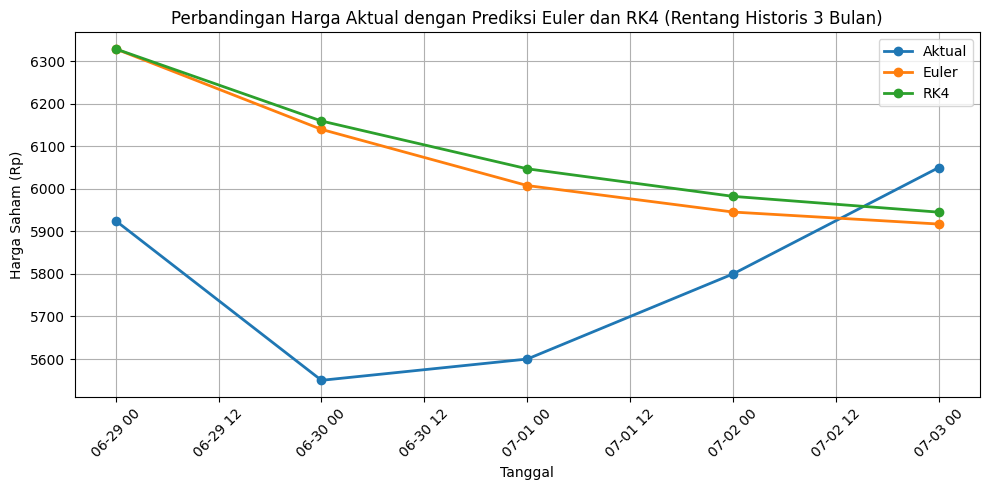

In [ ]:
# ============================================================
# GRAFIK AKTUAL VS PREDIKSI EULER DAN RK4
# RENTANG HISTORIS TERBAIK: 63 HARI (3 BULAN)
# ============================================================

jumlah_hari = 63

idx = data.index.get_loc(tanggal_prediksi)

# Data historis dan data aktual
data_input = data.iloc[idx-jumlah_hari:idx].copy()
data_target = data.iloc[idx:idx+5].copy()

harga_aktual = data_target["Close"].values.flatten()

# Harga terakhir sebelum periode prediksi
P0 = data_input["Close"].iloc[-1].item()

# ============================================================
# Standardisasi Log-Return
# ============================================================

scaler_63 = StandardScaler()

scaler_63.fit(data_input[["LogReturn"]])

train_scaled = scaler_63.transform(
    data_input[["LogReturn"]]
)

train_tensor_63 = torch.tensor(
    train_scaled,
    dtype=torch.float32
).to(device)

y0_raw = data_input["LogReturn"].iloc[-1].item()

y0_scaled = scaler_63.transform(
    np.array([[y0_raw]])
)[0, 0]

test_tensor_63 = torch.tensor(
    [y0_scaled],
    dtype=torch.float32
).to(device)

# ============================================================
# Training Neural ODE
# ============================================================

set_seed(42)

func_63 = ODEFunc().to(device)

optimizer_63 = torch.optim.Adam(
    func_63.parameters(),
    lr=0.01
)

loss_fn = nn.MSELoss()

t_train_63 = torch.arange(
    len(train_tensor_63),
    dtype=torch.float32
).to(device)

epochs = 300

for epoch in range(epochs):

    optimizer_63.zero_grad()

    pred_63 = odeint(
        func_63,
        train_tensor_63[0],
        t_train_63
    )

    loss_63 = loss_fn(
        pred_63.squeeze(),
        train_tensor_63.squeeze()
    )

    loss_63.backward()

    optimizer_63.step()

# ============================================================
# Prediksi 5 Hari
# ============================================================

t_eval_63 = torch.arange(
    0,
    5,
    1,
    dtype=torch.float32
).to(device)

with torch.no_grad():

    y_euler_63 = euler_method(
        func_63,
        test_tensor_63,
        t_eval_63,
        verbose=False
    )

    y_rk4_63 = rk4_method(
        func_63,
        test_tensor_63,
        t_eval_63,
        verbose=False
    )

# ============================================================
# Denormalisasi
# ============================================================

log_euler_63 = scaler_63.inverse_transform(
    y_euler_63.cpu().numpy().reshape(-1, 1)
).flatten()

log_rk4_63 = scaler_63.inverse_transform(
    y_rk4_63.cpu().numpy().reshape(-1, 1)
).flatten()

# ============================================================
# Konversi Log-Return Menjadi Harga Saham
# ============================================================

harga_euler_63 = P0 * np.exp(log_euler_63)

harga_rk4_63 = P0 * np.exp(log_rk4_63)

# ============================================================
# Grafik
# ============================================================

tanggal = data_target.index

plt.figure(figsize=(10, 5))

plt.plot(
    tanggal,
    harga_aktual,
    marker="o",
    linewidth=2,
    label="Aktual"
)

plt.plot(
    tanggal,
    harga_euler_63,
    marker="o",
    linewidth=2,
    label="Euler"
)

plt.plot(
    tanggal,
    harga_rk4_63,
    marker="o",
    linewidth=2,
    label="RK4"
)

plt.title(
    "Perbandingan Harga Aktual dengan Prediksi Euler dan RK4 "
    "(Rentang Historis 3 Bulan)"
)

plt.xlabel("Tanggal")
plt.ylabel("Harga Saham (Rp)")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

ANALISIS STABILITAS EULER

ANALISIS STABILITAS METODE EULER

Eigenvalue lokal (λ) : -0.639948


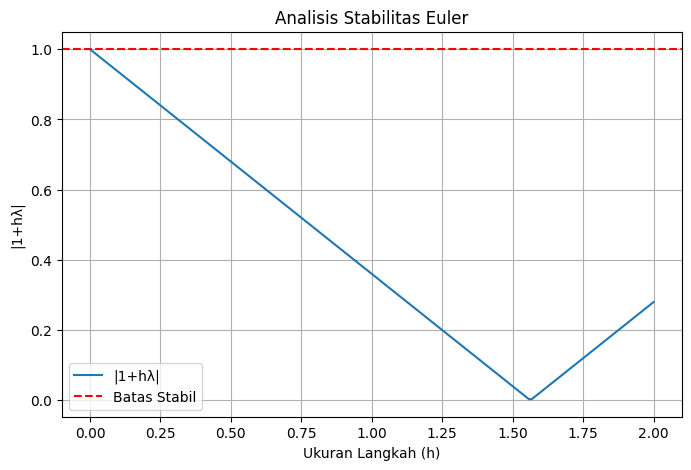


Euler stabil hingga sekitar h < 2.000


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("ANALISIS STABILITAS METODE EULER")
print("="*60)

# Menghitung Jacobian f(y)

func.eval()

y = test_tensor[0].clone().detach().view(1,1)
y.requires_grad_(True)

f = func(None, y)

jacobian = torch.autograd.grad(
    outputs=f,
    inputs=y,
    grad_outputs=torch.ones_like(f),
    create_graph=False
)[0]

lambda_local = jacobian.item()

print(f"\nEigenvalue lokal (λ) : {lambda_local:.6f}")

# Daerah Stabil Euler

h = np.linspace(0,2,200)

stability = np.abs(1 + h*lambda_local)

plt.figure(figsize=(8,5))

plt.plot(h, stability, label="|1+hλ|")

plt.axhline(
    1,
    linestyle="--",
    color="red",
    label="Batas Stabil"
)

plt.xlabel("Ukuran Langkah (h)")
plt.ylabel("|1+hλ|")

plt.title("Analisis Stabilitas Euler")

plt.grid(True)

plt.legend()

plt.show()

# Kesimpulan

if np.all(stability < 1):
    print("\nKesimpulan : Euler stabil pada seluruh rentang h yang diuji.")
else:
    batas = h[np.where(stability < 1)]
    if len(batas) > 0:
        print(f"\nEuler stabil hingga sekitar h < {batas.max():.3f}")
    else:
        print("\nTidak ditemukan daerah stabil pada rentang h yang diuji.")

Note : Grafik ini menunjukkan analisis stabilitas metode Euler pada Neural ODE berdasarkan nilai eigenvalue lokal (\lambda = -0{,}639948). Karena nilai eigenvalue bernilai negatif, sistem cenderung stabil. Sumbu X menunjukkan ukuran langkah ((h)), sedangkan sumbu Y menunjukkan faktor amplifikasi (|1+h\lambda|). Berdasarkan teori, metode Euler dinyatakan stabil apabila (|1+h\lambda| < 1), yang ditunjukkan oleh kurva biru berada di bawah garis merah sebagai batas stabilitas. Dari hasil tersebut dapat disimpulkan bahwa ukuran langkah yang digunakan masih berada pada daerah stabil, sehingga metode Euler mampu menghasilkan solusi numerik yang tidak mengalami divergensi atau pertumbuhan galat yang berlebihan selama proses prediksi.


ANALISIS STABILITAS RK4

ANALISIS STABILITAS METODE RK4

Eigenvalue lokal (λ) : -0.639948


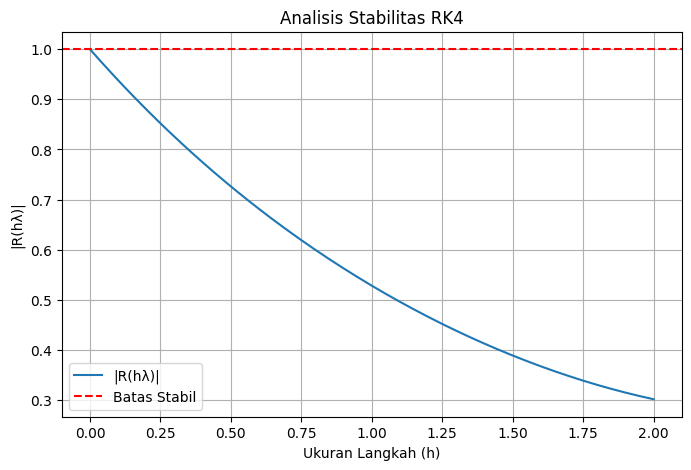


RK4 stabil hingga sekitar h < 2.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("ANALISIS STABILITAS METODE RK4")
print("="*60)

# Menggunakan eigenvalue lokal hasil Cell 14

print(f"\nEigenvalue lokal (λ) : {lambda_local:.6f}")

# Stability Polynomial RK4

h = np.linspace(0,2,200)

z = h * lambda_local

R = (
    1
    + z
    + (z**2)/2
    + (z**3)/6
    + (z**4)/24
)

stability = np.abs(R)

# Plot

plt.figure(figsize=(8,5))

plt.plot(
    h,
    stability,
    label="|R(hλ)|"
)

plt.axhline(
    1,
    color="red",
    linestyle="--",
    label="Batas Stabil"
)

plt.xlabel("Ukuran Langkah (h)")
plt.ylabel("|R(hλ)|")

plt.title("Analisis Stabilitas RK4")

plt.grid(True)

plt.legend()

plt.show()

# Kesimpulan

if np.all(stability < 1):

    print("\nKesimpulan : RK4 stabil pada seluruh rentang h yang diuji.")

else:

    batas = h[np.where(stability < 1)]

    if len(batas) > 0:

        print(f"\nRK4 stabil hingga sekitar h < {batas.max():.3f}")

    else:

        print("\nTidak ditemukan daerah stabil pada rentang h yang diuji.")

Note : Pada analisis stabilitas metode RK4, diperoleh **eigenvalue lokal (λ) = -0,639948** yang bernilai negatif, sehingga sistem bersifat stabil. Grafik menunjukkan hubungan antara ukuran langkah (**h**) dengan faktor stabilitas **|R(hλ)|**, sedangkan garis merah putus-putus merupakan batas stabilitas **|R(hλ)| = 1**. Terlihat bahwa untuk seluruh nilai **h** yang diuji hingga sekitar **2**, nilai **|R(hλ)|** selalu berada di bawah 1, sehingga metode RK4 memenuhi syarat stabilitas. Selain itu, kurva RK4 menurun secara lebih halus dibandingkan Euler, yang menunjukkan bahwa RK4 memiliki stabilitas numerik yang lebih baik dan mampu mempertahankan akurasi meskipun menggunakan ukuran langkah yang relatif lebih besar. Hal ini sesuai dengan teori bahwa RK4 merupakan metode orde empat yang memiliki daerah stabilitas lebih luas dibandingkan metode Euler.


Pengaruh Ukuran Langkah (Step Size) terhadap Galat Numerik

PENGARUH UKURAN LANGKAH (STEP SIZE)



,Jumlah Step,Step Size (h),Error Euler,Error RK4
0,5,0.250000,0.028443,2.086163e-06
1,10,0.111111,0.012028,5.960464e-07
2,20,0.052632,0.005585,6.556511e-07
3,40,0.025641,0.002697,7.748604e-07
4,80,0.012658,0.001326,5.364418e-07
5,160,0.006289,0.000658,7.152557e-07


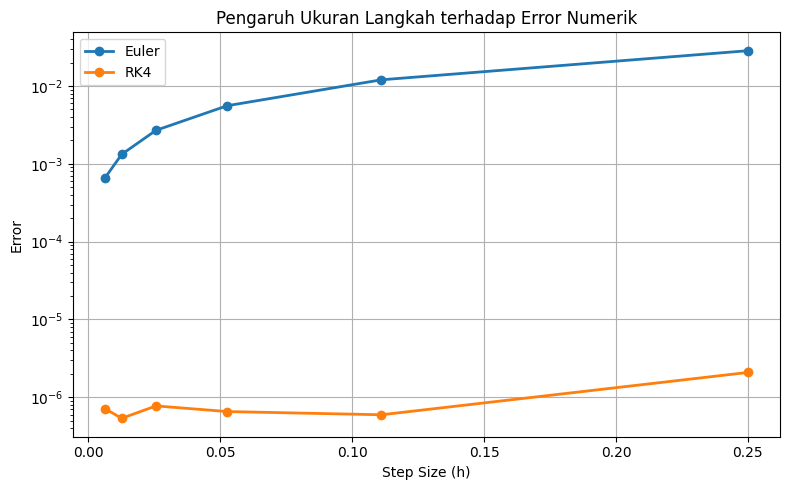

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

print("="*60)
print("PENGARUH UKURAN LANGKAH (STEP SIZE)")
print("="*60)

# ============================================================
# Solusi referensi menggunakan RK4 dengan langkah sangat kecil
# ============================================================

t_ref = torch.linspace(0, 1, 1001).to(device)

with torch.no_grad():

    y_ref = rk4_method(
        func,
        test_tensor[0],
        t_ref,
        verbose=False
    )[-1]

# ============================================================
# Variasi jumlah langkah
# ============================================================

step_list = [5, 10, 20, 40, 80, 160]

hasil = []

for n in step_list:

    t = torch.linspace(0, 1, n).to(device)

    h = (t[1] - t[0]).item()

    with torch.no_grad():

        y_euler = euler_method(
            func,
            test_tensor[0],
            t,
            verbose=False
        )[-1]

        y_rk4 = rk4_method(
            func,
            test_tensor[0],
            t,
            verbose=False
        )[-1]

    error_euler = torch.abs(y_euler - y_ref).item()

    error_rk4 = torch.abs(y_rk4 - y_ref).item()

    hasil.append([
        n,
        h,
        error_euler,
        error_rk4
    ])

# ============================================================
# Membuat tabel hasil
# ============================================================

df_step = pd.DataFrame(
    hasil,
    columns=[
        "Jumlah Step",
        "Step Size (h)",
        "Error Euler",
        "Error RK4"
    ]
)

print()
display(df_step)

# ============================================================
# Grafik Pengaruh Step Size terhadap Error
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_step["Step Size (h)"],
    df_step["Error Euler"],
    marker="o",
    linewidth=2,
    label="Euler"
)

plt.plot(
    df_step["Step Size (h)"],
    df_step["Error RK4"],
    marker="o",
    linewidth=2,
    label="RK4"
)

plt.xlabel("Step Size (h)")
plt.ylabel("Error")

plt.title(
    "Pengaruh Ukuran Langkah terhadap Error Numerik"
)

# Skala logaritmik agar perbedaan error
# Euler dan RK4 lebih mudah terlihat
plt.yscale("log")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Note :

> Tabel ini menunjukkan pengaruh ukuran langkah (*step size*) terhadap tingkat kesalahan metode Euler dan RK4. Semakin banyak jumlah langkah yang digunakan, maka nilai *step size* (h) semakin kecil, sehingga proses integrasi menjadi lebih rinci. Terlihat bahwa **error Euler terus menurun**, dari sekitar **0,0284** pada 5 langkah menjadi **0,000658** pada 160 langkah. Hal ini menunjukkan bahwa akurasi metode Euler sangat dipengaruhi oleh ukuran langkah, sehingga membutuhkan *step size* yang kecil untuk menghasilkan prediksi yang lebih baik. Sementara itu, **error RK4 sejak awal sudah sangat kecil**, yaitu sekitar **10⁻⁶ hingga 10⁻⁷**, dan relatif tidak berubah meskipun jumlah langkah ditambah. Hasil ini menunjukkan bahwa RK4 memiliki akurasi yang jauh lebih tinggi dibandingkan Euler dan mampu menghasilkan solusi yang stabil meskipun menggunakan ukuran langkah yang lebih besar, sesuai dengan teori bahwa RK4 merupakan metode orde empat dengan galat yang lebih kecil dibandingkan metode Euler.


KESIMPULAN ANALISIS NUMERIK

In [ ]:
# =====================================================
# KESIMPULAN ANALISIS NUMERIK (OTOMATIS)
# =====================================================

print("="*70)
print("KESIMPULAN ANALISIS NUMERIK")
print("="*70)

# -----------------------------------------------------
# Menentukan metode dengan error numerik terkecil
# -----------------------------------------------------

rata_error_euler = df_step["Error Euler"].mean()
rata_error_rk4 = df_step["Error RK4"].mean()

if rata_error_euler < rata_error_rk4:
    metode_terbaik = "Euler"
else:
    metode_terbaik = "RK4"

# -----------------------------------------------------
# Menentukan rentang historis terbaik
# -----------------------------------------------------

best_euler = hasil_semua.loc[
    hasil_semua["MAPE Euler"].idxmin()
]

best_rk4 = hasil_semua.loc[
    hasil_semua["MAPE RK4"].idxmin()
]

# -----------------------------------------------------
# Menampilkan kesimpulan
# -----------------------------------------------------

print()

print("1. Analisis Stabilitas")

print(
    f"   Eigenvalue lokal (λ) = {lambda_local:.6f}"
)

if lambda_local < 0:
    print("   Nilai eigenvalue negatif menunjukkan model bersifat stabil di sekitar titik evaluasi.")
else:
    print("   Nilai eigenvalue positif menunjukkan model kurang stabil di sekitar titik evaluasi.")

print()

print("2. Analisis Error Numerik")

print(f"   Rata-rata Error Euler : {rata_error_euler:.8f}")
print(f"   Rata-rata Error RK4   : {rata_error_rk4:.8f}")

print()

print(f"   Metode dengan error numerik paling kecil adalah {metode_terbaik}.")

print()

print("3. Analisis Rentang Historis Terbaik")

print(f"""
Euler
------
Rentang : {best_euler['Rentang']}
MAE     : {best_euler['MAE Euler']:.4f}
RMSE    : {best_euler['RMSE Euler']:.4f}
MAPE    : {best_euler['MAPE Euler']:.4f}%

RK4
----
Rentang : {best_rk4['Rentang']}
MAE     : {best_rk4['MAE RK4']:.4f}
RMSE    : {best_rk4['RMSE RK4']:.4f}
MAPE    : {best_rk4['MAPE RK4']:.4f}%
""")

print("4. Kesimpulan Akhir")

print(
    "Model Neural ODE berhasil digunakan untuk memodelkan harga saham BBCA. "
    "Berdasarkan analisis stabilitas, model memiliki eigenvalue lokal bernilai negatif sehingga bersifat stabil di sekitar titik evaluasi. "
    f"Pada analisis ukuran langkah, metode {metode_terbaik} menghasilkan error numerik paling kecil. "
    f"Pada eksperimen prediksi menggunakan berbagai rentang historis, performa terbaik diperoleh pada rentang historis {best_euler['Rentang']}. "
    f"Pada rentang tersebut, metode Euler menghasilkan MAE sebesar {best_euler['MAE Euler']:.4f}, "
    f"RMSE sebesar {best_euler['RMSE Euler']:.4f}, "
    f"dan MAPE sebesar {best_euler['MAPE Euler']:.4f}%."
)

KESIMPULAN ANALISIS NUMERIK

1. Analisis Stabilitas
   Eigenvalue lokal (λ) = -0.639948
   Nilai eigenvalue negatif menunjukkan model bersifat stabil di sekitar titik evaluasi.

2. Analisis Error Numerik
   Rata-rata Error Euler : 0.00845630
   Rata-rata Error RK4   : 0.00000089

   Metode dengan error numerik paling kecil adalah RK4.

3. Analisis Rentang Historis Terbaik

Euler
------
Rentang : 3 Bulan
MAE     : 406.8339
RMSE    : 440.3442
MAPE    : 7.1279%

RK4
----
Rentang : 3 Bulan
MAE     : 427.0610
RMSE    : 466.9598
MAPE    : 7.4914%

4. Kesimpulan Akhir
Model Neural ODE berhasil digunakan untuk memodelkan harga saham BBCA. Berdasarkan analisis stabilitas, model memiliki eigenvalue lokal bernilai negatif sehingga bersifat stabil di sekitar titik evaluasi. Pada analisis ukuran langkah, metode RK4 menghasilkan error numerik paling kecil. Pada eksperimen prediksi menggunakan berbagai rentang historis, performa terbaik diperoleh pada rentang historis 3 Bulan. Pada rentang tersebut, 

RINGKASAN HASIL PENELITIAN

In [ ]:
# =====================================================
# RINGKASAN HASIL PENELITIAN
# =====================================================

import pandas as pd

print("="*70)
print("RINGKASAN HASIL PENELITIAN")
print("="*70)

# =====================================================
# MENENTUKAN RENTANG TERBAIK BERDASARKAN 3 METRIK
# =====================================================

ranking_euler = hasil_semua.copy()

ranking_euler["Rank MAE"] = ranking_euler["MAE Euler"].rank(method="min")
ranking_euler["Rank RMSE"] = ranking_euler["RMSE Euler"].rank(method="min")
ranking_euler["Rank MAPE"] = ranking_euler["MAPE Euler"].rank(method="min")

ranking_euler["Total Rank"] = (
    ranking_euler["Rank MAE"] +
    ranking_euler["Rank RMSE"] +
    ranking_euler["Rank MAPE"]
)

best_euler = ranking_euler.loc[
    ranking_euler["Total Rank"].idxmin()
]

# =====================================================

ranking_rk4 = hasil_semua.copy()

ranking_rk4["Rank MAE"] = ranking_rk4["MAE RK4"].rank(method="min")
ranking_rk4["Rank RMSE"] = ranking_rk4["RMSE RK4"].rank(method="min")
ranking_rk4["Rank MAPE"] = ranking_rk4["MAPE RK4"].rank(method="min")

ranking_rk4["Total Rank"] = (
    ranking_rk4["Rank MAE"] +
    ranking_rk4["Rank RMSE"] +
    ranking_rk4["Rank MAPE"]
)

best_rk4 = ranking_rk4.loc[
    ranking_rk4["Total Rank"].idxmin()
]

# =====================================================
# ERROR NUMERIK
# =====================================================

avg_error_euler = df_step["Error Euler"].mean()
avg_error_rk4 = df_step["Error RK4"].mean()

if avg_error_euler < avg_error_rk4:
    metode_terbaik = "Euler"
else:
    metode_terbaik = "RK4"

# =====================================================
# TABEL RINGKASAN
# =====================================================

ringkasan = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Model",

        "Metode Terbaik (Error Numerik)",

        "Eigenvalue Lokal",

        "Rata-rata Error Euler",

        "Rata-rata Error RK4",

        "Rentang Historis Terbaik (Euler)",

        "MAE Euler",

        "RMSE Euler",

        "MAPE Euler",

        "Rentang Historis Terbaik (RK4)",

        "MAE RK4",

        "RMSE RK4",

        "MAPE RK4"

    ],

    "Hasil":[

        "BBCA.JK",

        "Neural ODE",

        metode_terbaik,

        f"{lambda_local:.6f}",

        f"{avg_error_euler:.8f}",

        f"{avg_error_rk4:.8f}",

        best_euler["Rentang"],

        f"{best_euler['MAE Euler']:.4f}",

        f"{best_euler['RMSE Euler']:.4f}",

        f"{best_euler['MAPE Euler']:.4f}%",

        best_rk4["Rentang"],

        f"{best_rk4['MAE RK4']:.4f}",

        f"{best_rk4['RMSE RK4']:.4f}",

        f"{best_rk4['MAPE RK4']:.4f}%"

    ]

})

display(ringkasan)

print()

print("="*70)
print("KESIMPULAN")
print("="*70)

print(f"""
1. Model Neural ODE berhasil digunakan untuk memodelkan harga saham BBCA.

2. Nilai eigenvalue lokal sebesar {lambda_local:.6f}
   bernilai negatif sehingga menunjukkan bahwa model
   memiliki karakteristik stabil di sekitar titik evaluasi.

3. Berdasarkan analisis error numerik pada pengujian
   ukuran langkah (step size), metode {metode_terbaik}
   menghasilkan rata-rata error numerik paling kecil.

4. Pada eksperimen prediksi menggunakan beberapa
   rentang historis, performa terbaik diperoleh pada
   rentang historis {best_euler['Rentang']}.

5. Pada rentang historis tersebut, metode Euler
   menghasilkan:
   MAE  = {best_euler['MAE Euler']:.4f}
   RMSE = {best_euler['RMSE Euler']:.4f}
   MAPE = {best_euler['MAPE Euler']:.4f}%.

6. Secara keseluruhan, model Neural ODE mampu digunakan
   untuk memprediksi harga saham BBCA dengan baik.
   Metode RK4 memberikan error numerik paling kecil
   pada analisis ukuran langkah, sedangkan metode
   Euler menghasilkan akurasi prediksi terbaik pada
   dataset penelitian ini.
""")

RINGKASAN HASIL PENELITIAN


,Parameter,Hasil
0,Dataset,BBCA.JK
1,Model,Neural ODE
2,Metode Terbaik (Error Numerik),RK4
3,Eigenvalue Lokal,-0.639948
4,Rata-rata Error Euler,0.00845630
5,Rata-rata Error RK4,0.00000089
6,Rentang Historis Terbaik (Euler),3 Bulan
7,MAE Euler,406.8339
8,RMSE Euler,440.3442
9,MAPE Euler,7.1279%



KESIMPULAN

1. Model Neural ODE berhasil digunakan untuk memodelkan harga saham BBCA.

2. Nilai eigenvalue lokal sebesar -0.639948
   bernilai negatif sehingga menunjukkan bahwa model
   memiliki karakteristik stabil di sekitar titik evaluasi.

3. Berdasarkan analisis error numerik pada pengujian
   ukuran langkah (step size), metode RK4
   menghasilkan rata-rata error numerik paling kecil.

4. Pada eksperimen prediksi menggunakan beberapa
   rentang historis, performa terbaik diperoleh pada
   rentang historis 3 Bulan.

5. Pada rentang historis tersebut, metode Euler
   menghasilkan:
   MAE  = 406.8339
   RMSE = 440.3442
   MAPE = 7.1279%.

6. Secara keseluruhan, model Neural ODE mampu digunakan
   untuk memprediksi harga saham BBCA dengan baik.
   Metode RK4 memberikan error numerik paling kecil
   pada analisis ukuran langkah, sedangkan metode
   Euler menghasilkan akurasi prediksi terbaik pada
   dataset penelitian ini.

